In [2]:
pip install mysql-connector-python

     ---------------------------------------- 16.4/16.4 MB 2.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import mysql.connector


In [52]:
conn=mysql.connector.connect(host="localhost",
                             user="root",
                             password="Barsha@123",
                             database="online_sales")
if conn.is_connected:
    print("connected to mysql database")

connected to mysql database


In [43]:
query='select * from sales'

In [53]:
df=pd.read_sql(query,conn)
df

C:\Users\barsh\anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,transaction_id,customer_id,product_id,transaction_date,quantity,total_value,price
0,T00001,C0199,P067,2024-08-25,1,300.68,300.68
1,T00002,C0092,P034,2024-12-16,2,434.10,217.05
2,T00003,C0028,P057,2024-01-25,4,958.80,239.70
3,T00004,C0004,P049,2024-07-19,4,591.80,147.95
4,T00005,C0150,P087,2024-05-25,2,580.34,290.17
...,...,...,...,...,...,...,...
995,T00996,C0189,P056,2024-01-31,1,16.08,16.08
996,T00997,C0164,P023,2024-11-01,4,1818.12,454.53
997,T00998,C0024,P011,2024-06-19,2,522.40,261.20
998,T00999,C0024,P064,2024-02-24,1,452.42,452.42


In [18]:
# find out top 10 customers
query1="""select customer_id,transaction_id,total_value
          from sales
          order by total_value
          desc limit 10
         """
top_10_customers=pd.read_sql(query1,conn)
top_10_customers


,customer_id,transaction_id,total_value
0,C0082,T00928,1991.04
1,C0065,T00499,1954.52
2,C0044,T00307,1927.12
3,C0171,T00224,1879.08
4,C0051,T00070,1879.08
5,C0013,T00503,1879.08
6,C0169,T00558,1879.08
7,C0018,T00922,1839.44
8,C0091,T00012,1825.12
9,C0168,T00034,1825.12


In [19]:
# find out top 10 products
query2="""select product_id,transaction_id,total_value
          from sales
          order by total_value
          desc limit 10
         """
top_10_customers=pd.read_sql(query2,conn)
top_10_customers


C:\Users\barsh\anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,product_id,transaction_id,total_value
0,P075,T00928,1991.04
1,P032,T00499,1954.52
2,P045,T00307,1927.12
3,P017,T00224,1879.08
4,P017,T00070,1879.08
5,P017,T00503,1879.08
6,P017,T00558,1879.08
7,P037,T00922,1839.44
8,P041,T00012,1825.12
9,P041,T00034,1825.12


In [20]:
# highest priced product

query3="""select product_id,price
          from sales
          order by price
          desc limit 1
         """
top_10_customers=pd.read_sql(query3,conn)
top_10_customers


C:\Users\barsh\anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,product_id,price
0,P075,497.76


In [23]:
# total quantity of products sold

query4="""select sum(quantity) as total_quantities_sold
          from sales

         """
top_10_customers=pd.read_sql(query4,conn)
top_10_customers


C:\Users\barsh\anaconda3\lib\site-packages\pandas\io\sql.py:762: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


,total_quantities_sold
0,2537.0


In [47]:
df

,transaction_id,customer_id,product_id,transaction_date,quantity,total_value,price
0,T00001,C0199,P067,2024-08-25,1,300.68,300.68
1,T00002,C0092,P034,2024-12-16,2,434.10,217.05
2,T00003,C0028,P057,2024-01-25,4,958.80,239.70
3,T00004,C0004,P049,2024-07-19,4,591.80,147.95
4,T00005,C0150,P087,2024-05-25,2,580.34,290.17
...,...,...,...,...,...,...,...
995,T00996,C0189,P056,2024-01-31,1,16.08,16.08
996,T00997,C0164,P023,2024-11-01,4,1818.12,454.53
997,T00998,C0024,P011,2024-06-19,2,522.40,261.20
998,T00999,C0024,P064,2024-02-24,1,452.42,452.42


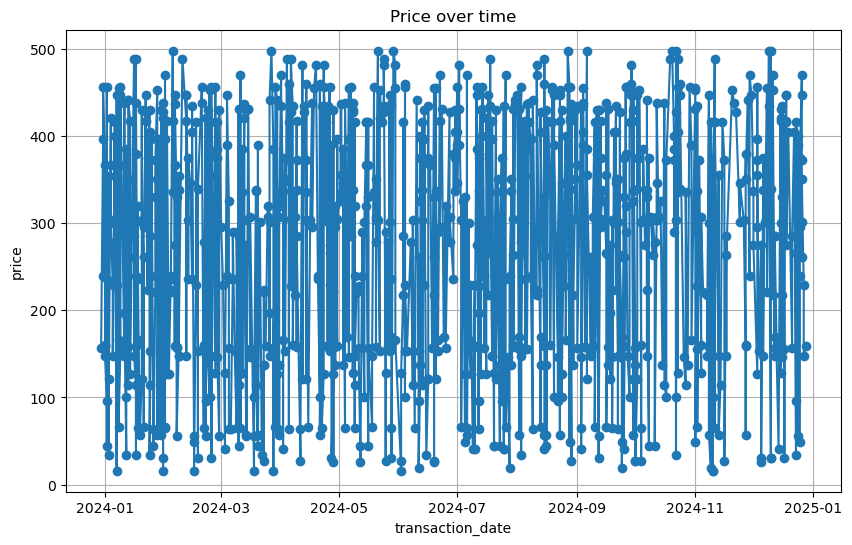

In [70]:
# creating a line chart
import matplotlib.pyplot as plt
import pandas as pd
df= pd.DataFrame(df)
df['transaction_date']=pd.to_datetime(df['transaction_date'],errors='coerce')
df=df.sort_values(by='transaction_date')
plt.figure(figsize=(10,6))
plt.plot(df['transaction_date'],df['price'],marker='o',linestyle='-')
plt.title('Price over time')
plt.xlabel('transaction_date')
plt.ylabel('price')
plt.grid(True)


plt.savefig("internship_day7_taskfigure1.png")
plt.show()